In [1]:
import pandas as pd

df = pd.read_csv('/content/sakshamjaiswalsrccgbo_17607822412605405.csv', encoding='latin-1')

In [2]:
display(df.head())
display(df.info())

,Country,State,Year,Month,Name Of The Fertilizer Used,"Required Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1","Available Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1"
0,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2016","December, 2016",Diammonium Phosphate,0.0,1000.0
1,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2016","December, 2016",Monoammonium Phosphate,0.0,0.0
2,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2016","December, 2016",Muriate of Potash (MOP) or Potassium Chloride,0.0,0.0
3,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2016","December, 2016",Single super Phosphate,0.0,0.0
4,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2016","December, 2016",Triple superphosphate,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10259 entries, 0 to 10258
Data columns (total 7 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Country                                                                10259 non-null  object 
 1   State                                                                  10259 non-null  object 
 2   Year                                                                   10259 non-null  object 
 3   Month                                                                  10259 non-null  object 
 4   Name Of The Fertilizer Used                                            10259 non-null  object 
 5   Required Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1   10259 non-null  float64
 6   Available Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1  10256 non-null  

None

In [3]:
missing_values = df.isnull().sum()
display(missing_values)

,0
Country,0
State,0
Year,0
Month,0
Name Of The Fertilizer Used,0
"Required Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1",0
"Available Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1",3


In [4]:
df.dropna(subset=['Available Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1'], inplace=True)
missing_values_after_drop = df.isnull().sum()
display(missing_values_after_drop)

,0
Country,0
State,0
Year,0
Month,0
Name Of The Fertilizer Used,0
"Required Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1",0
"Available Fertilizer Quantity (UOM:MT(MetricTonne)), Scaling Factor:1",0


In [5]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {len(df)}")

Number of duplicate rows: 0


/tmp/ipython-input-279963438.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_major['Required_Quantity'] = pd.to_numeric(df_major['Required_Quantity'], errors='coerce')


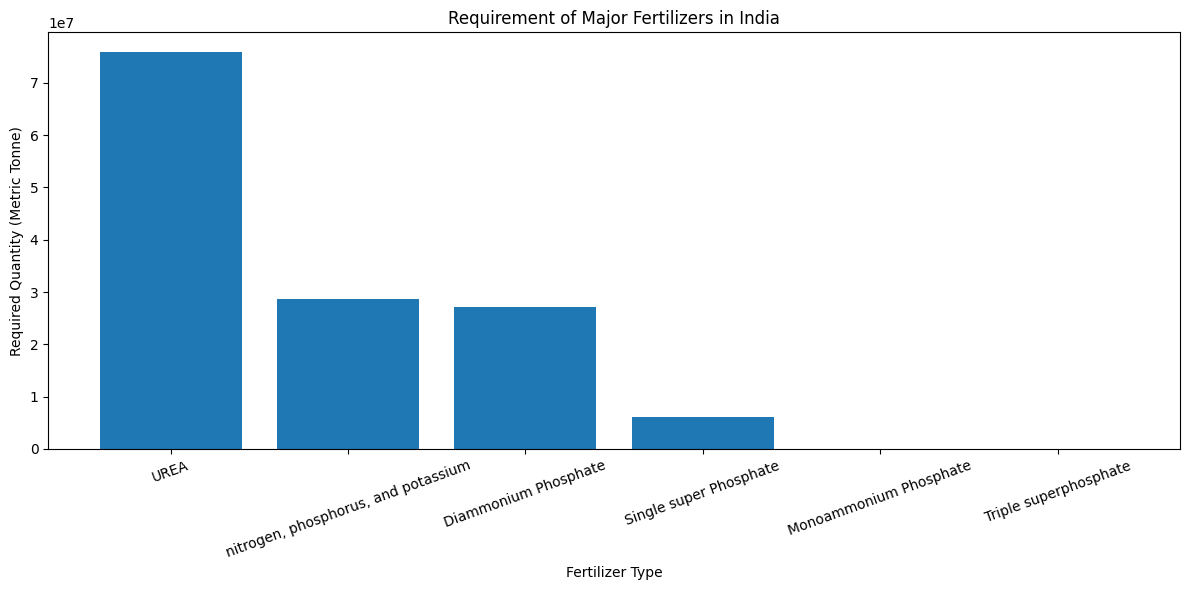

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# Fix column names if necessary
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Define list of 7 major fertilizers
major_fertilizers = [
    'UREA',
    'Diammonium Phosphate',
    'Muriate of Potash MOP or Potassium Chloride',
    'Single super Phosphate',
    'Triple superphosphate',
    'nitrogen, phosphorus, and potassium',
    'Monoammonium Phosphate'
]

# Filter for these fertilizers only
df_major = df[df['Fertilizer'].isin(major_fertilizers)]

# Convert quantity to numeric (ignore errors)
df_major['Required_Quantity'] = pd.to_numeric(df_major['Required_Quantity'], errors='coerce')

# Aggregate total requirement per fertilizer
fert_sum = df_major.groupby('Fertilizer')['Required_Quantity'].sum().reset_index().sort_values('Required_Quantity', ascending=False)

# Plot
plt.figure(figsize=(12,6))
plt.bar(fert_sum['Fertilizer'], fert_sum['Required_Quantity'])
plt.title('Requirement of Major Fertilizers in India')
plt.xlabel('Fertilizer Type')
plt.ylabel('Required Quantity (Metric Tonne)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


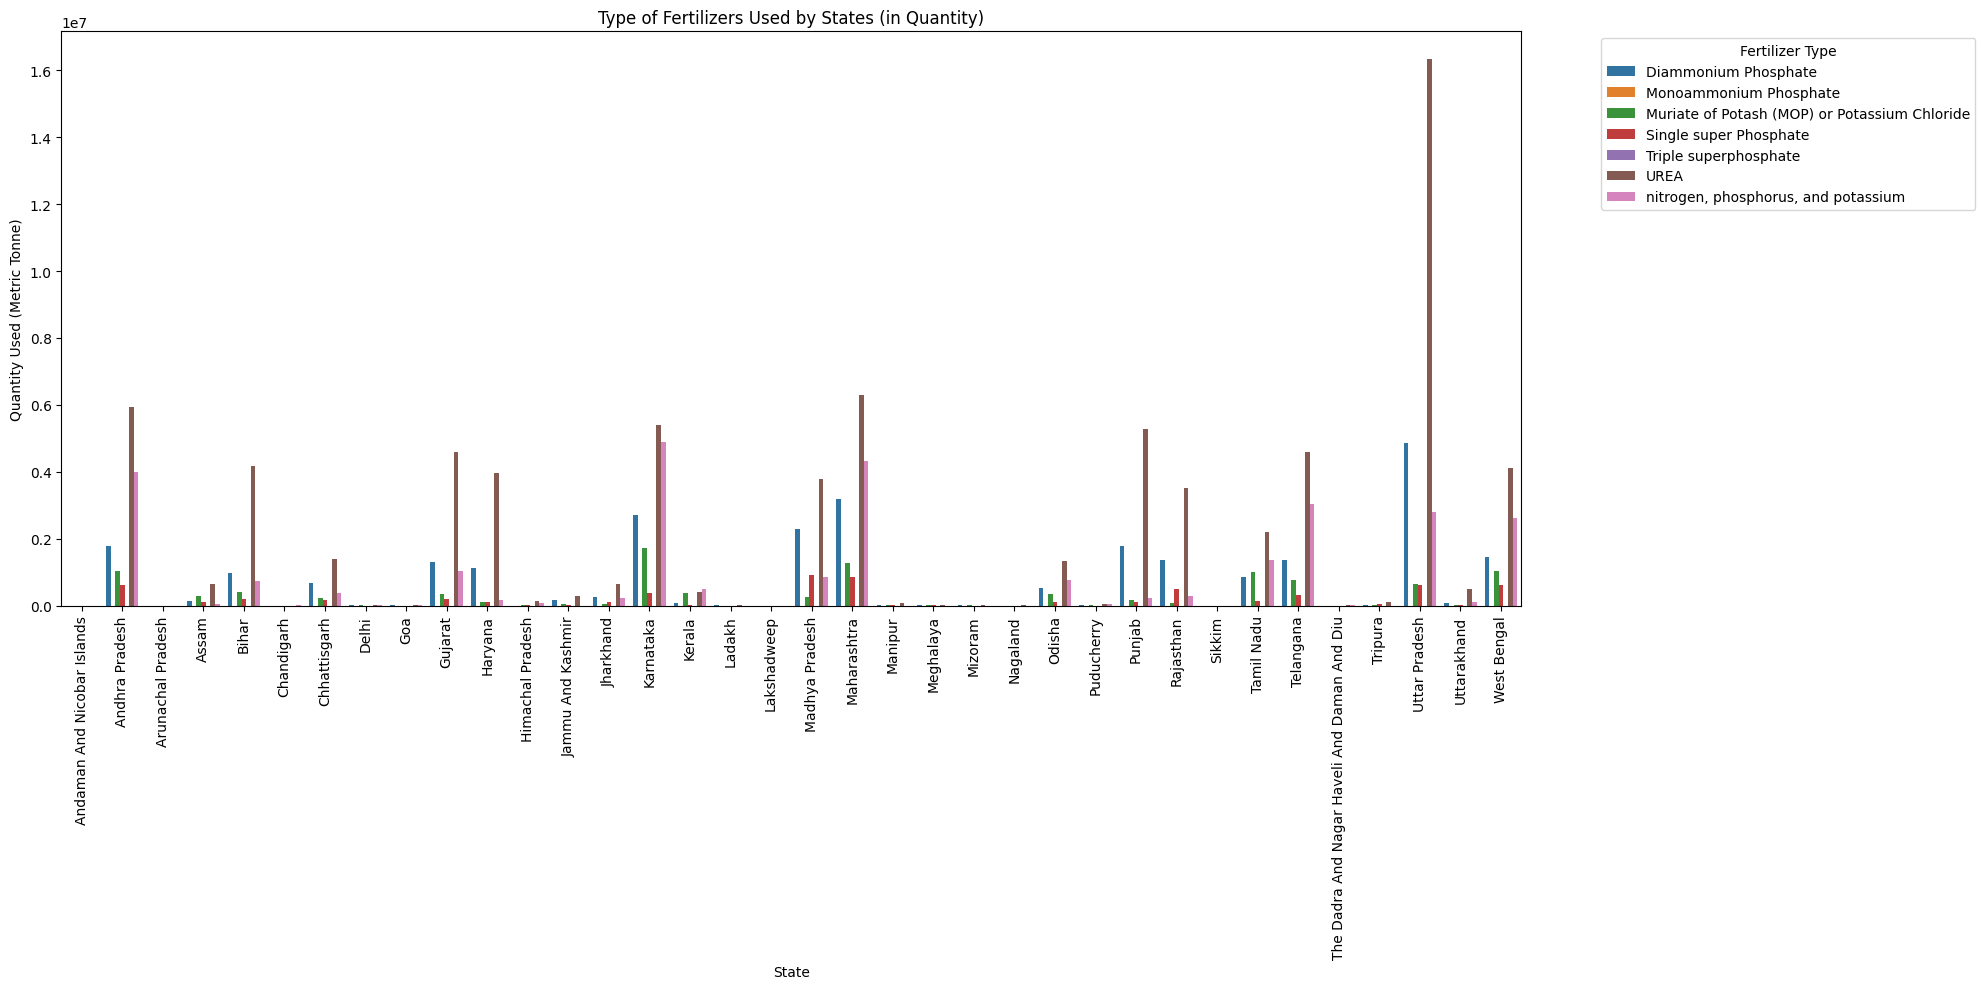

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file with proper delimiter handling, if the default doesn't work, try delimiter=None for auto-detect
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# If necessary, extract actual columns (cleaning or splitting may be required if the header got merged)
# For example, rename columns if auto-detected as a single header string
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Convert quantity columns to numeric
df['Required_Quantity'] = pd.to_numeric(df['Required_Quantity'], errors='coerce')

# Aggregate required quantity by state and fertilizer type
grouped = df.groupby(['State', 'Fertilizer'])['Required_Quantity'].sum().reset_index()

# Plot using seaborn
plt.figure(figsize=(20,10))
sns.barplot(data=grouped, x='State', y='Required_Quantity', hue='Fertilizer')
plt.title('Type of Fertilizers Used by States (in Quantity)')
plt.xticks(rotation=90)
plt.ylabel('Quantity Used (Metric Tonne)')
plt.xlabel('State')
plt.legend(title='Fertilizer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# Rename columns for ease of use (adjust based on your actual column names)
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Convert quantity columns to numeric
df['Required_Quantity'] = pd.to_numeric(df['Required_Quantity'], errors='coerce')
df['Available_Quantity'] = pd.to_numeric(df['Available_Quantity'], errors='coerce')

# Aggregate total quantities by state
agg = df.groupby('State')[['Required_Quantity', 'Available_Quantity']].sum().reset_index()

# Calculate gap and fulfillment %
agg['Gap'] = agg['Required_Quantity'] - agg['Available_Quantity']
agg['Fulfillment_Percentage'] = (agg['Available_Quantity'] / agg['Required_Quantity']) * 100

# Optional: Fill or remove rows where required quantity is zero to avoid division issues
agg = agg[agg['Required_Quantity'] > 0]

# Display result
print(agg)

# Optional: to get overall totals across all states
overall = agg[['Required_Quantity', 'Available_Quantity']].sum()
overall_gap = overall['Required_Quantity'] - overall['Available_Quantity']
overall_fulfillment = (overall['Available_Quantity'] / overall['Required_Quantity']) * 100

print(f"Overall Required Quantity: {overall['Required_Quantity']}")
print(f"Overall Available Quantity: {overall['Available_Quantity']}")
print(f"Overall Gap: {overall_gap}")
print(f"Overall Fulfillment: {overall_fulfillment:.2f}%")


                                           State  Required_Quantity  \
0                    Andaman And Nicobar Islands       7.480000e+03   
1                                 Andhra Pradesh       1.334651e+07   
2                              Arunachal Pradesh       4.130000e+03   
3                                          Assam       1.235950e+06   
4                                          Bihar       6.476610e+06   
5                                     Chandigarh       1.500000e+04   
6                                   Chhattisgarh       2.841590e+06   
7                                          Delhi       4.998000e+04   
8                                            Goa       3.385000e+04   
9                                        Gujarat       7.465110e+06   
10                                       Haryana       5.452500e+06   
11                              Himachal Pradesh       2.184200e+05   
12                             Jammu And Kashmir       5.055565e+05   
13    

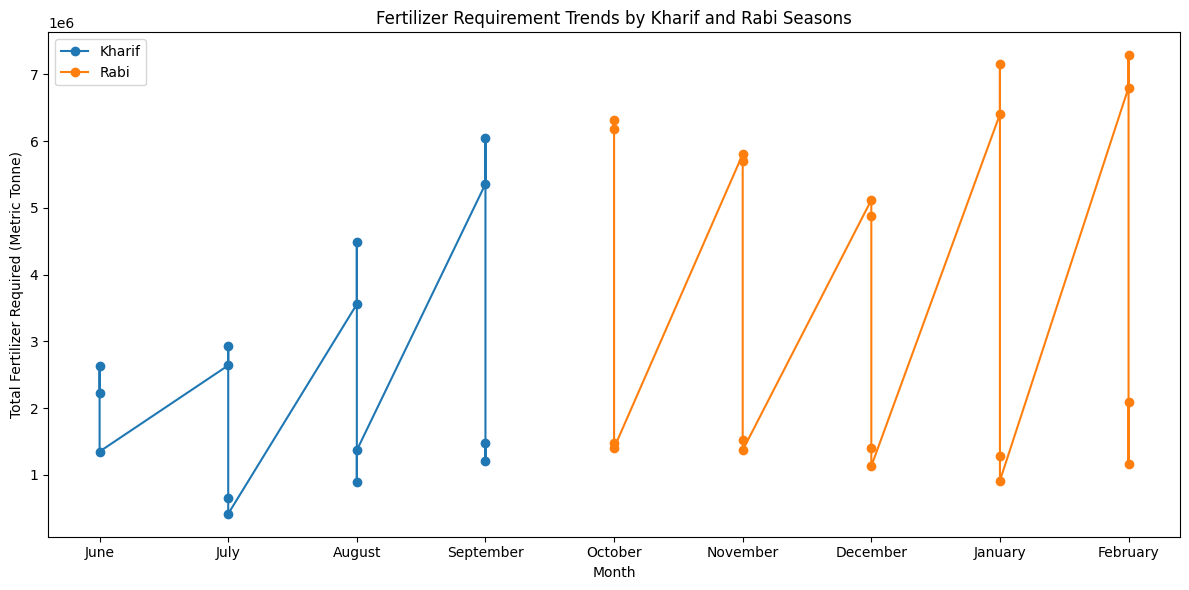

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# Rename columns for ease of use (adjust if needed)
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Convert Required_Quantity to numeric
df['Required_Quantity'] = pd.to_numeric(df['Required_Quantity'], errors='coerce')

# Define month to season mapping
kharif_months = ['June', 'July', 'August', 'September', 'October']
rabi_months = ['October', 'November', 'December', 'January', 'February']

def assign_season(month):
    month_clean = month.split(',')[0].strip()  # Clean month strings if needed
    if month_clean in kharif_months and month_clean in rabi_months:
        # Assign 'October' to Rabi based on typical cycle
        if month_clean == 'October':
            return 'Rabi'
        else:
            return 'Other'
    elif month_clean in kharif_months:
        return 'Kharif'
    elif month_clean in rabi_months:
        return 'Rabi'
    else:
        return 'Other'

df['Season'] = df['Month'].apply(assign_season)

# Filter for Kharif and Rabi seasons
df_seasons = df[df['Season'].isin(['Kharif', 'Rabi'])]

# Aggregate total fertilizer requirement by season and month
season_month_agg = df_seasons.groupby(['Season', 'Month'])['Required_Quantity'].sum().reset_index()

# Sort months within each season according to typical cropping cycle
kharif_order = ['June', 'July', 'August', 'September', 'October']
rabi_order = ['October', 'November', 'December', 'January', 'February']

season_month_agg['Month_Clean'] = season_month_agg['Month'].apply(lambda x: x.split(',')[0].strip())

# Plot trend lines for each season
plt.figure(figsize=(12,6))

for season in ['Kharif', 'Rabi']:
    data = season_month_agg[season_month_agg['Season'] == season]
    if season == 'Kharif':
        # Filter months present in the data for this season before ordering
        kharif_months_present = [month for month in kharif_order if month in data['Month_Clean'].unique()]
        data = data.set_index('Month_Clean').loc[kharif_months_present].reset_index()
    else:
        # Filter months present in the data for this season before ordering
        rabi_months_present = [month for month in rabi_order if month in data['Month_Clean'].unique()]
        data = data.set_index('Month_Clean').loc[rabi_months_present].reset_index()
    plt.plot(data['Month_Clean'], data['Required_Quantity'], marker='o', label=season)

plt.title('Fertilizer Requirement Trends by Kharif and Rabi Seasons')
plt.xlabel('Month')
plt.ylabel('Total Fertilizer Required (Metric Tonne)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# Load dataset
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# Rename columns (adjust as needed)
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Convert quantities to numeric
df['Required_Quantity'] = pd.to_numeric(df['Required_Quantity'], errors='coerce')
df['Available_Quantity'] = pd.to_numeric(df['Available_Quantity'], errors='coerce')

# Calculate shortage/surplus
df['Gap'] = df['Available_Quantity'] - df['Required_Quantity']

# Define conditions for shortage and surplus
df['Status'] = df['Gap'].apply(lambda x: 'Shortage' if x < 0 else ('Surplus' if x > 0 else 'Match'))

# Aggregate counts of shortages and surpluses by State and Fertilizer
summary = df.groupby(['State', 'Fertilizer', 'Status']).size().unstack(fill_value=0).reset_index()

# Sort by shortage count descending to find most frequently short states/fertilizers
shortage_summary = summary.sort_values(by='Shortage', ascending=False)

print("Top states/fertilizers facing shortages:")
print(shortage_summary[['State', 'Fertilizer', 'Shortage']].head(10))

print("\nTop states/fertilizers facing surpluses:")
# Sort by surplus count descending
surplus_summary = summary.sort_values(by='Surplus', ascending=False)
print(surplus_summary[['State', 'Fertilizer', 'Surplus']].head(10))


Top states/fertilizers facing shortages:
Status           State                           Fertilizer  Shortage
103          Karnataka                                 UREA        44
215          Telangana                                 UREA        38
250        West Bengal                                 UREA        36
54               Delhi                                 UREA        35
98           Karnataka                 Diammonium Phosphate        35
12      Andhra Pradesh                                 UREA        34
210          Telangana                 Diammonium Phosphate        33
216          Telangana  nitrogen, phosphorus, and potassium        31
245        West Bengal                 Diammonium Phosphate        31
236      Uttar Pradesh                                 UREA        30

Top states/fertilizers facing surpluses:
Status           State             Fertilizer  Surplus
46        Chhattisgarh  Triple superphosphate       44
109             Kerala  Triple superp

Correlation between Required and Available quantities by State (aggregated): 0.9664
Correlation between Required and Available quantities by Year: 0.8992


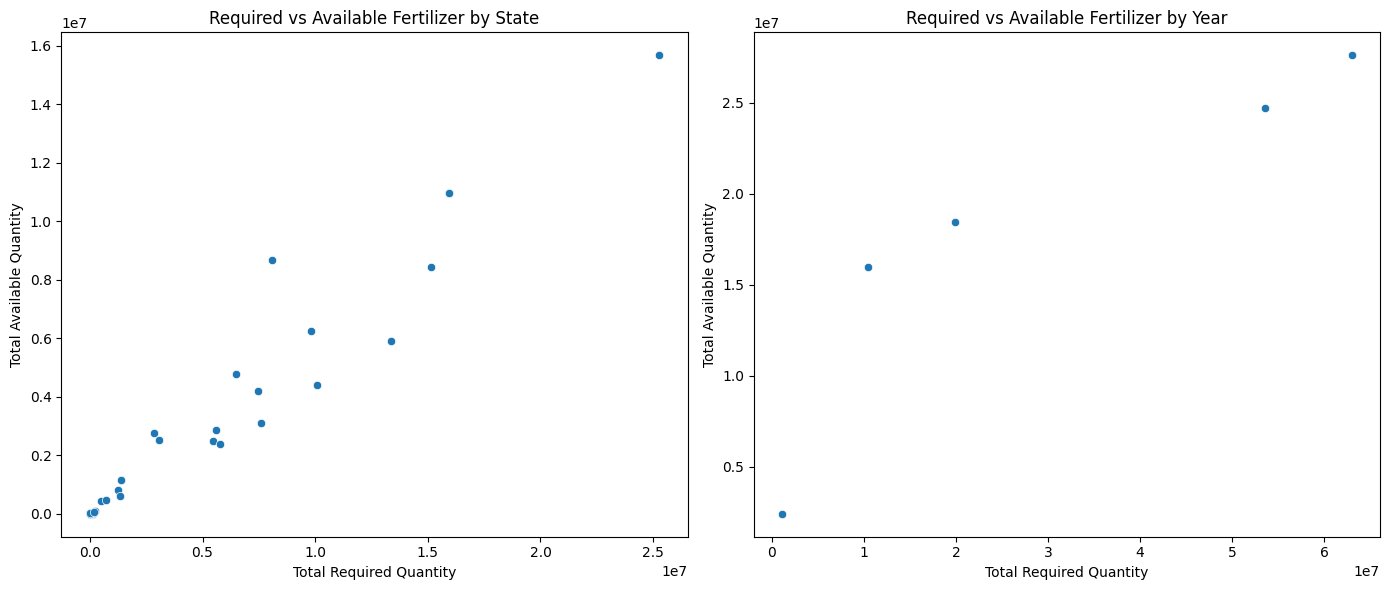

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# Rename columns for ease of use
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Convert quantities to numeric
df['Required_Quantity'] = pd.to_numeric(df['Required_Quantity'], errors='coerce')
df['Available_Quantity'] = pd.to_numeric(df['Available_Quantity'], errors='coerce')

# Correlation by State across entire period
state_corr = df.groupby('State')[['Required_Quantity', 'Available_Quantity']].sum().corr().iloc[0,1]

print(f"Correlation between Required and Available quantities by State (aggregated): {state_corr:.4f}")

# Correlation by Year (time) across all states
# Extract year if necessary (assuming Year column includes string "Financial Year Apr - Mar, 2014")
df['Year_Extracted'] = df['Year'].str.extract(r'(\d{4})').astype(float)

year_corr_data = df.groupby('Year_Extracted')[['Required_Quantity', 'Available_Quantity']].sum().dropna()
year_corr = year_corr_data.corr().iloc[0,1]

print(f"Correlation between Required and Available quantities by Year: {year_corr:.4f}")

# Visualize correlation using scatterplots
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
state_data = df.groupby('State')[['Required_Quantity', 'Available_Quantity']].sum().reset_index()
sns.scatterplot(data=state_data, x='Required_Quantity', y='Available_Quantity')
plt.title('Required vs Available Fertilizer by State')
plt.xlabel('Total Required Quantity')
plt.ylabel('Total Available Quantity')

plt.subplot(1,2,2)
sns.scatterplot(data=year_corr_data, x='Required_Quantity', y='Available_Quantity')
plt.title('Required vs Available Fertilizer by Year')
plt.xlabel('Total Required Quantity')
plt.ylabel('Total Available Quantity')

plt.tight_layout()
plt.show()


DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cpsiuev/k_gz4zt8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cpsiuev/at870jhc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95716', 'data', 'file=/tmp/tmp7cpsiuev/k_gz4zt8.json', 'init=/tmp/tmp7cpsiuev/at870jhc.json', 'output', 'file=/tmp/tmp7cpsiuev/prophet_modelt6cds16o/prophet_model-20251018103323.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
10:33:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:33:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


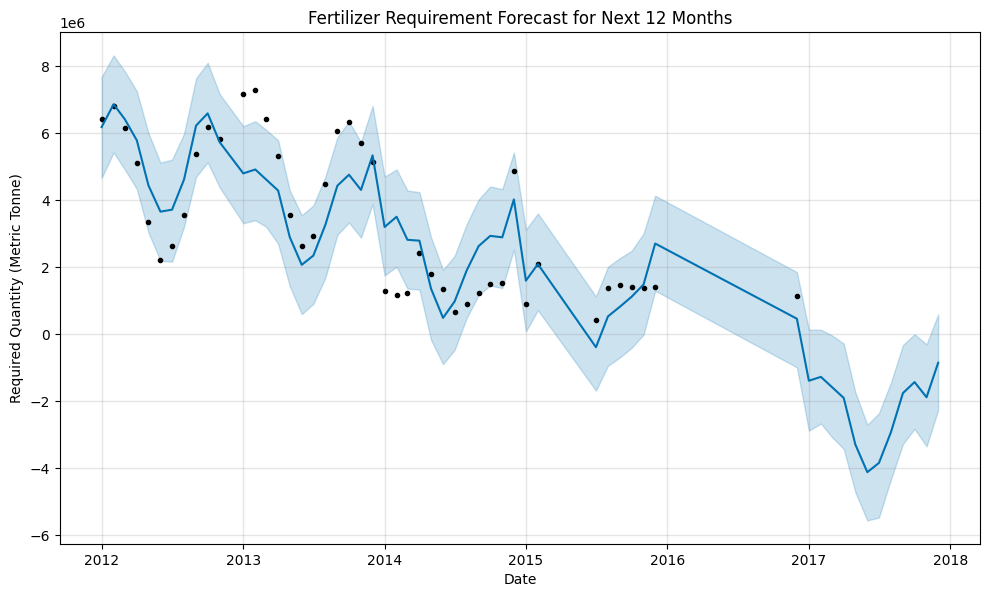

In [16]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# Rename columns (adjust as needed)
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Convert quantities to numeric
df['Required_Quantity'] = pd.to_numeric(df['Required_Quantity'], errors='coerce')

# Create a proper date column by combining Year and Month (assuming Year has financial info, parse year)
df['Year_Extracted'] = df['Year'].str.extract(r'(\d{4})').astype(int)

# Clean month names for date construction
df['Month_Clean'] = df['Month'].str.split(',').str[0].str.strip()

# Map month names to month numbers
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,'July':7,
             'August':8,'September':9,'October':10,'November':11,'December':12}
df['Month_Num'] = df['Month_Clean'].map(month_map)

# Create date column (using 1st day of month)
df['Date'] = pd.to_datetime(dict(year=df['Year_Extracted'], month=df['Month_Num'], day=1))

# Aggregate monthly fertilizer requirement across India
monthly_data = df.groupby('Date')['Required_Quantity'].sum().reset_index()

# Rename columns for Prophet
monthly_data = monthly_data.rename(columns={'Date':'ds', 'Required_Quantity':'y'})

# Instantiate and fit the model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(monthly_data)

# Create future dataframe for next 12 months
future = model.make_future_dataframe(periods=12, freq='MS')  # MS=month start

# Predict future requirements
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)
plt.title('Fertilizer Requirement Forecast for Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Required Quantity (Metric Tonne)')
plt.show()


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('sakshamjaiswalsrccgbo_17607822412605405.csv')

# Rename columns for convenience
df.columns = ['Country', 'State', 'Year', 'Month', 'Fertilizer', 'Required_Quantity', 'Available_Quantity']

# Extract year as integer from Year string
df['Year_Extracted'] = df['Year'].str.extract(r'(\d{4})').astype(int)

# Convert month name to month number
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,'July':7,
             'August':8,'September':9,'October':10,'November':11,'December':12}
df['Month_Clean'] = df['Month'].str.split(',').str[0].str.strip()
df['Month_Num'] = df['Month_Clean'].map(month_map)

# Drop rows with missing Required_Quantity or Month_Num
df = df.dropna(subset=['Required_Quantity', 'Month_Num'])

# Encode categorical variables
le_state = LabelEncoder()
le_fertilizer = LabelEncoder()

df['State_Encoded'] = le_state.fit_transform(df['State'])
df['Fertilizer_Encoded'] = le_fertilizer.fit_transform(df['Fertilizer'])

# Prepare features and target
X = df[['Year_Extracted', 'Month_Num', 'State_Encoded', 'Fertilizer_Encoded']]
y = df['Required_Quantity'].astype(float)

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Sample prediction for next month for a specific state and fertilizer
sample_input = pd.DataFrame({
    'Year_Extracted': [2026],
    'Month_Num': [11],  # November
    'State_Encoded': [le_state.transform(['Karnataka'])[0]],  # encode state
    'Fertilizer_Encoded': [le_fertilizer.transform(['UREA'])[0]]  # encode fertilizer type
})

predicted_demand = model.predict(sample_input)
print(f"Predicted fertilizer demand (November 2026, Karnataka, UREA): {predicted_demand[0]:.2f}")


Mean Squared Error: 423022653.65
R2 Score: 0.82
Predicted fertilizer demand (November 2026, Karnataka, UREA): 165700.50
